# Ropedia Academy — A8 · Human–scene & human–object interaction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/A8.ipynb)

> **Optimizes a body against contact + non-penetration and shows before/after 3D plots of it being pushed onto the floor and out of the obstacle.**
>
> 在接触 + 非穿插约束下优化身体，并用前后 3D 图展示它被推到地面、挤出障碍物之外。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/A8

vertices still penetrating: 0


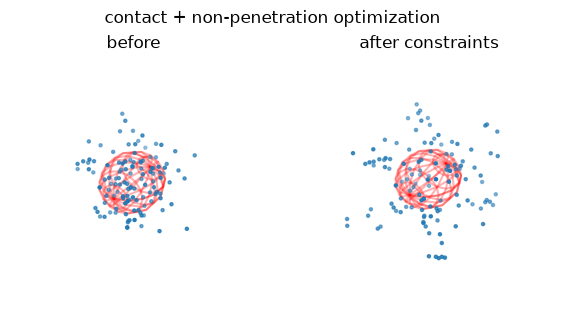

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
# Human-scene: optimize a body to be SUPPORTED and NOT penetrate the scene.

# ---------- INPUT: body vertices + a scene obstacle (as an SDF) ----------
body = (torch.randn(120, 3)*0.3 + torch.tensor([0,0.5,0.])).requires_grad_()
scene_sdf = lambda p: (p - torch.tensor([0.,0.5,0.])).norm(dim=-1) - 0.4   # obstacle
before = body.detach().clone()

# ---------- MODEL: descend contact + non-penetration losses (physics = supervision) ----------
opt = torch.optim.Adam([body], lr=0.05)
for _ in range(120):
    opt.zero_grad()
    contact = body[:5, 1].abs().mean()                       # some verts ON the floor
    penetration = (-scene_sdf(body)).clamp(min=0).mean()      # not INSIDE the obstacle
    (contact + penetration).backward(); opt.step()

# ---------- OUTPUT: penetration count + before/after 3D plots ----------
print("vertices still penetrating:", int((scene_sdf(body) < 0).sum()))
fig = plt.figure(figsize=(7, 3.5))
u, v = np.mgrid[0:2*np.pi:16j, 0:np.pi:8j]
sx, sy, sz = 0.4*np.cos(u)*np.sin(v), 0.5+0.4*np.sin(u)*np.sin(v), 0.4*np.cos(v)
for i, (pts, name) in enumerate([(before,'before'),(body.detach(),'after constraints')]):
    ax = fig.add_subplot(1,2,i+1, projection='3d'); p = pts.numpy()
    ax.plot_wireframe(sx, sz, sy, color='r', alpha=0.3)
    ax.scatter(p[:,0], p[:,2], p[:,1], s=5); ax.set_title(name); ax.set_axis_off()
plt.suptitle("contact + non-penetration optimization"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/A8
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks